In [4]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA , NVIDIAEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document

from langgraph.graph import StateGraph , START , END

from dotenv import load_dotenv
from pydantic import BaseModel , Field
from typing import TypedDict , List , Literal

import time

d:\GenAI\LangGraph\myenvAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
load_dotenv()

True

In [6]:
docs = (

    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Policies.pdf').load() + 
    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Profile.pdf').load() + 
    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Policies.pdf').load()
)

In [7]:
# Text splitting
chunk = RecursiveCharacterTextSplitter(chunk_size = 600 , chunk_overlap = 150).split_documents(docs)

In [8]:
embedding = NVIDIAEmbeddings()
vector_store = FAISS.from_documents(chunk , embedding)
retriever = vector_store.as_retriever(search_kwargs = {'k' : 4})

In [9]:
llm = ChatNVIDIA(model = 'openai/gpt-oss-120b')

In [23]:
# Define state
class State(TypedDict):
    question : str
    need_retrieval : bool

    docs : List[Document]
    relevant_docs : List[Document]

    context : str
    answer : str

    # Post-generation verification
    issup : Literal['fully_support' , 'partially_support' , 'no_support']
    evidence : list[str]

In [24]:
class RetrieverDecision(BaseModel):
    should_retrieve : bool = Field(... , description='True if external documents are needed to answer relaibly, else False')


decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'You decide whether retrieval is needed.\n'
            'Return JSON that matches this schema:\n'
            '{{should_retrieve : boolan}}\n\n'
            'Guidelines:\n'
            '- Should_retrieve=True if answering requires specific facts, citations , info likely not in the model.\n'
            '- Should_retrieve=False for general explanations , definations, or reasoning that does not need source.\n'
            '- If unsure , choose True'
        ),
        ('human' , 'Question : {question}'),
    ]
)

# IMPORTANT : no content for structure output
should_retrieve_llm = llm.with_structured_output(RetrieverDecision)


def decide_retrieval(state : State):

    decision : RetrieverDecision = should_retrieve_llm.invoke(

        decide_retrieval_prompt.format_messages(question= state['question'])
    )

    return {'need_retrieval' : decision.should_retrieve}

In [25]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'Answer the question using only your general knowledge.\n'
            'Do NOT assume access to external documents.\n'
            'If you unsure or the answer require specific sources, say:\n'
            'I do not know based on my general knowledge.'
        ),
        ('human' , '{question}')
    ]
)

def generate_direct(state : State):

    out = llm.invoke(

        direct_generation_prompt.format_messages(question = state['question'])
    )

    return {'answer' : out.content}

In [26]:
def retrieve(state : State):

    return {'docs' : retriever.invoke(state['question'])}

In [27]:
class RelavenceDecision(BaseModel):

    is_relevant : bool = Field(... , description='True if the documnent helps answer the question , else False')

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'You are judging document relevance.\n'
            'Return JSON that matches this schema.\n'
            '{{is_relevant : boolean}}\n\n'
            'A document is relevant if it contains information useful for answering the question.\n'
        ),
        ('human' , 'Question : \n{question}\n\nDocument : \n {document}')
    ]
)

relevance_llm = llm.with_structured_output(RelavenceDecision)

def is_relevant(state : State):

    relevant_doc : List[Document] = []

    for doc in state.get('docs' , ''):

        decision : RelavenceDecision = relevance_llm.invoke(

            is_relevant_prompt.format_messages(
                question = state['question'],
                document = doc.page_content
            )
        )


        if decision.is_relevant:
            relevant_doc.append(doc)


    return {'relevant_docs' : relevant_doc}

In [28]:
rag_generate_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'You are a business RAG asisstant.\n'
            'Answer the user question using ONLY the provided context.\n'
            'If the context does not contain enough information , say.\n'
            'NO relevant document found.\n'
            'Do not use outsider knowledge.\n'
        ),
        (
            'human',
            'Question : \n{question}\n\n'
            'Context  : \n{context}\n\n'
        )
    ]
)

def generate_from_context(state : State):

    # stuff relevant docs into one block
    context = '\n\n'.join([d.page_content for d in state.get('relevant_docs' , [])])

    if not context:
        return {'answer' : 'No relevant document found.' , 'context' : ''}
    

    out = llm.invoke(

        rag_generate_prompt.format_messages(
            question = state['question'],
            context = context
        )
    )

    return {'answer' : out.content , 'context' : context}

In [29]:
def no_relevant_docs(state : State):
    
    return {'answer' : 'No relevant document found.' , 'context' : ''}

In [30]:
class IsSUPDecision(BaseModel):

    issup : Literal['fully_support' , 'paritally_support' , 'no_support']
    evidence : List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'You are verifuing whether the answer is supported by the CONTEXT.\n'
            'Return JOSN with keys: issup , evidence.\n'
            'issup must be one of : fully_support , paritally_support , no_support.\n\n'
            'How to decided issup:\n'
            '- fully_supported:\n'
            '  Every meaningful claim is explictly support by CONTEXT, and the answer does not introduce\n'
            '  any '
        ),
        (
            'human',
            'Question:\n {question}\n\n'
            'Answer : \n{answer}\n\n'
            'Context : \n{context}'
            
        )
    ]
)


issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state : State):

    decision : IsSUPDecision = issup_llm.invoke(

        issup_prompt.format_messages(
            question = state['question'],
            answer = state['answer'],
            context = state['context']
        )
    )

    return {'issup' : decision.issup , 'evidence' : decision.evidence}

In [31]:
def route_after_decide(state : State) -> Literal['generate_direct' , 'retrieve']:

    if state['need_retrieval']:
        return 'retrieve'
    
    else:
        return 'generate_direct'

In [32]:
def route_after_relevance(state : State) -> Literal['generate_from_context' , 'no_relevant_docs']:

    if state['relevant_docs'] and len(state['relevant_docs']) > 0:
        return 'generate_from_context'
    
    else:
        return 'no_relevant_docs'

In [33]:
builder = StateGraph(State)

# Add nodes
builder.add_node('decide_retrieval' , decide_retrieval)
builder.add_node('generate_direct' , generate_direct)
builder.add_node('is_relevant' , is_relevant)
builder.add_node('generate_from_context' , generate_from_context)
builder.add_node('no_relevant_docs' , no_relevant_docs)
builder.add_node('is_sup' , is_sup)
builder.add_node('retrieve' , retrieve)

# Add edges
builder.add_edge(START , 'decide_retrieval')

builder.add_conditional_edges(
    'decide_retrieval',

    route_after_decide,
    {
        'generate_direct' : 'generate_direct',
        'retrieve' : 'retrieve'
    }
)

builder.add_edge('retrieve' , 'is_relevant')

builder.add_conditional_edges(
    'is_relevant',

    route_after_relevance,
    {
        'generate_from_context' : 'generate_from_context',
        'no_relevant_docs' : 'no_relevant_docs'
    }
)
builder.add_edge('generate_from_context' , 'is_sup')
builder.add_edge('generate_direct' , END)
builder.add_edge('is_sup' , END)
builder.add_edge('no_relevant_docs' , END)

# compile the graph

app = builder.compile()

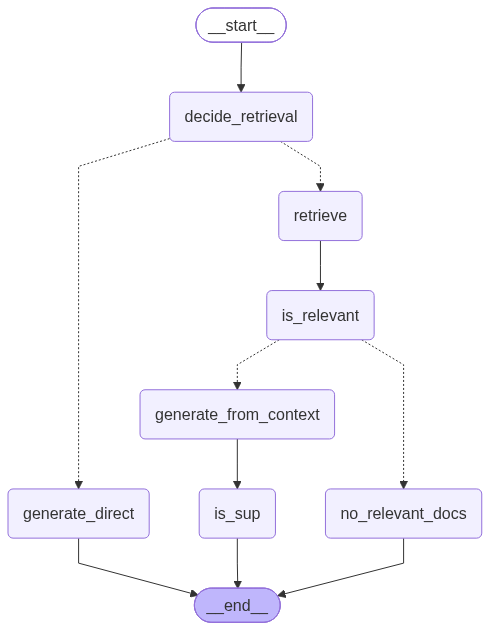

In [34]:
app

In [35]:
result = app.invoke(
        {
            "question": 'Describe NextAI"s company cultural',
            "docs": [],
            "relevant_docs": [],
            "context": "",
            "answer": "",
            "issup": "",
            "evidence": [],
        },
    )

print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 2
issup: fully_support
evidence: ['Customer Obsession – Every solution starts with a real business pain point.', 'Transparency – Clear communication with customers and within teams.', 'Accountability – Ownership of outcomes, not just tasks.', 'Security First – Data protection is non‑negotiable.', 'Continuous Improvement – Iterate, learn, and improve relentlessly.', 'Our mission is to simplify access to organizational knowledge, automate repetitive workflows, and help teams operate with speed, clarity, and confidence.', 'We focus on practical AI adoption rather than experimental research.']
answer: NextAI’s culture is built around practical, outcome‑driven AI work and a team‑first mindset.  
Key elements of the culture include:

* **Customer‑obsessed** – Every project begins with a real business pain point, keeping the team focused on delivering tangible value.  
* **Transparency** – Open, clear communication is expected both with customers 

In [ ]:
# How many employees does NextAI have
# Describe NextAI's company cultural
# Do NexaAI plans include a free trail? If yes , how many days

In [ ]:
for doc in result['relevant_docs']:

    print(doc)